In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from gena_expression.conditions import DescriptionLookup
from gena_expression.dna import Genome
from gena_expression.inference import SequenceModel
from gena_expression.tracks import Track

In [ ]:
# Paths and constants used by later cells

from pathlib import Path

GENALM_HOME = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark")

os.environ["GENALM_HOME"] = GENALM_HOME.__str__()

GENA_LM_ROOT = GENALM_HOME / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_FILE = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_FILE}::ExpressionCounts"

MODEL_CHECKPOINT = GENALM_HOME / "models" / "expression_model_v1-1" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / 'configs' / "final.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5" # CHANGE THIS LINE


TOKEN_LEN_FOR_FETCH = 15
NUM_BEFORE = 511
DNA_MAX_SEQ_LEN = 1024
DESC_MAX_SEQ_LEN = 510

We will use ATAC-seq experiment from ENCODE as an example: https://www.encodeproject.org/files/ENCFF770EAV/@@download/ENCFF770EAV.bigWig

In [3]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/dna/genome.py:437: RuntimeWarning: Plain GTF/GFF annotations are not supported directly for fast interval queries; using existing compressed annotation /workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz. debug={'plain_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf', 'compressed_path': '/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/genomes/hg38/gencode.v29.primary_assembly.annotation_UCSC_names.gtf.gz'}
  return _TabixGtfAnnotation(cls._ensure_tabix_gtf(path))
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_

In [ ]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=DNA_MAX_SEQ_LEN,
    num_before=NUM_BEFORE,
    desc_max_seq_len=DESC_MAX_SEQ_LEN,
    token_len_for_fetch=TOKEN_LEN_FOR_FETCH,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/inference/model.py:162: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

In [5]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=['IMR-90'],
)

In [15]:
sequence = genome.sequence_around(center=120524275, chrom='chr1', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr1',
              center=120524275,
              size=10_000)

In [19]:
prediction.track().to_frame()[['token_id', 'token', 'length', 'start', 'end', 'track']]

,token_id,token,length,start,end,track
0,106,AAAAG,5,1566,1571,0.111816
1,9646,TAAGAGAC,8,1571,1579,0.150391
2,399,TTGCCC,6,1579,1585,0.109863
3,6023,AAACTTCC,8,1585,1593,0.170898
4,219,ACAGC,5,1593,1598,0.111328
...,...,...,...,...,...,...
1017,8721,AGAATAGG,8,8235,8243,1.093750
1018,2527,TCTTAAG,7,8243,8250,1.218750
1019,11318,ATATATTGC,9,8250,8259,1.101562
1020,196,ATAGC,5,8259,8264,0.863281


In [ ]:
a

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

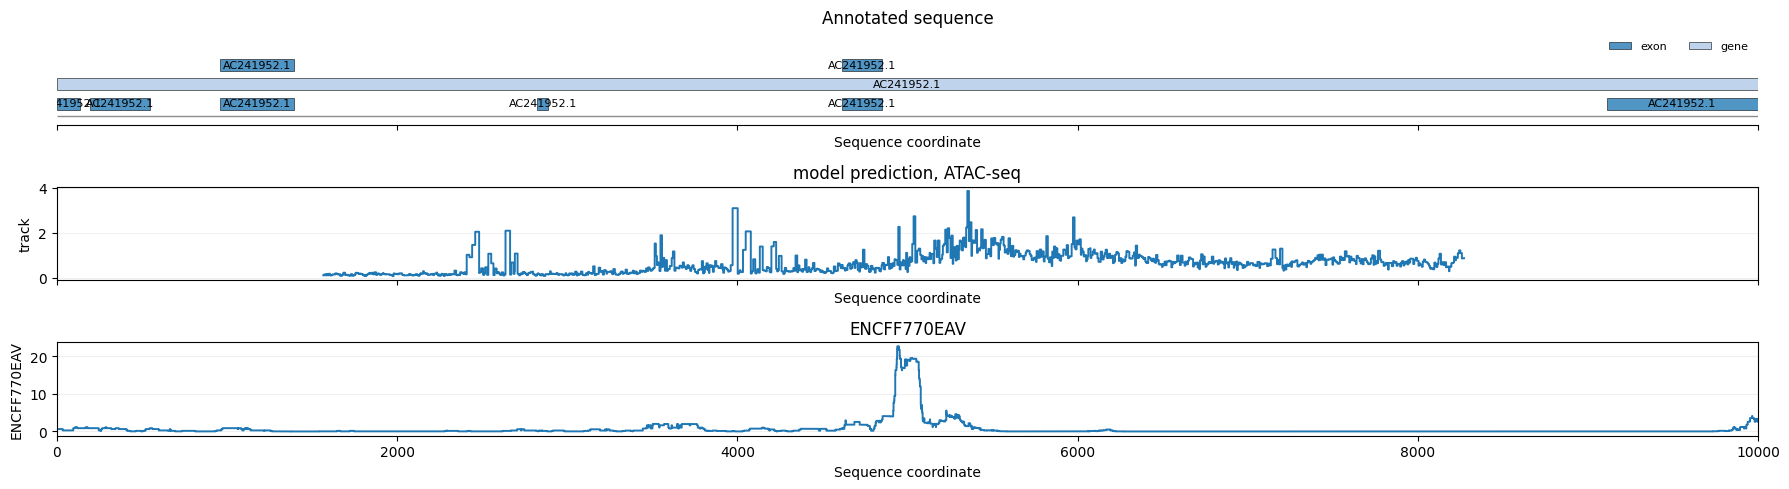

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [15]:
sequence = genome.sequence_around(center=159_869_000, chrom='chr1', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr1',
              center=159_869_000,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

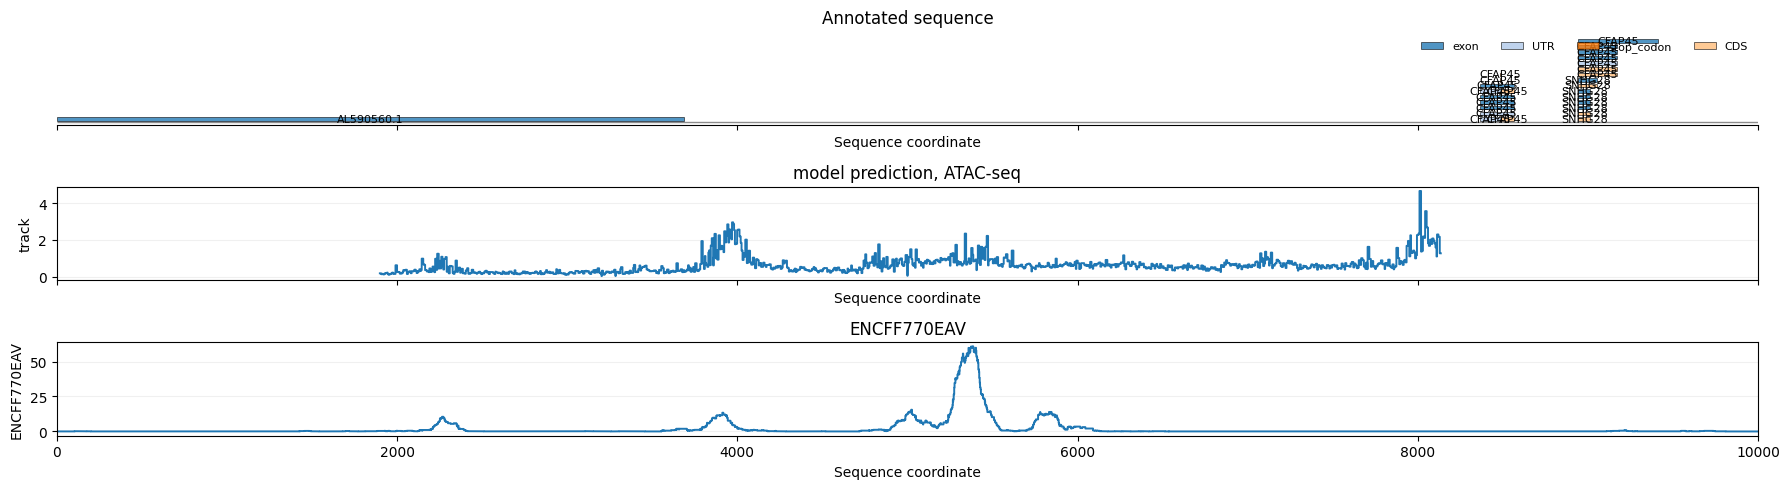

In [19]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [12]:
sequence = genome.sequence_around(center=159_924_000, chrom='chr1', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr1',
              center=159_924_000,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

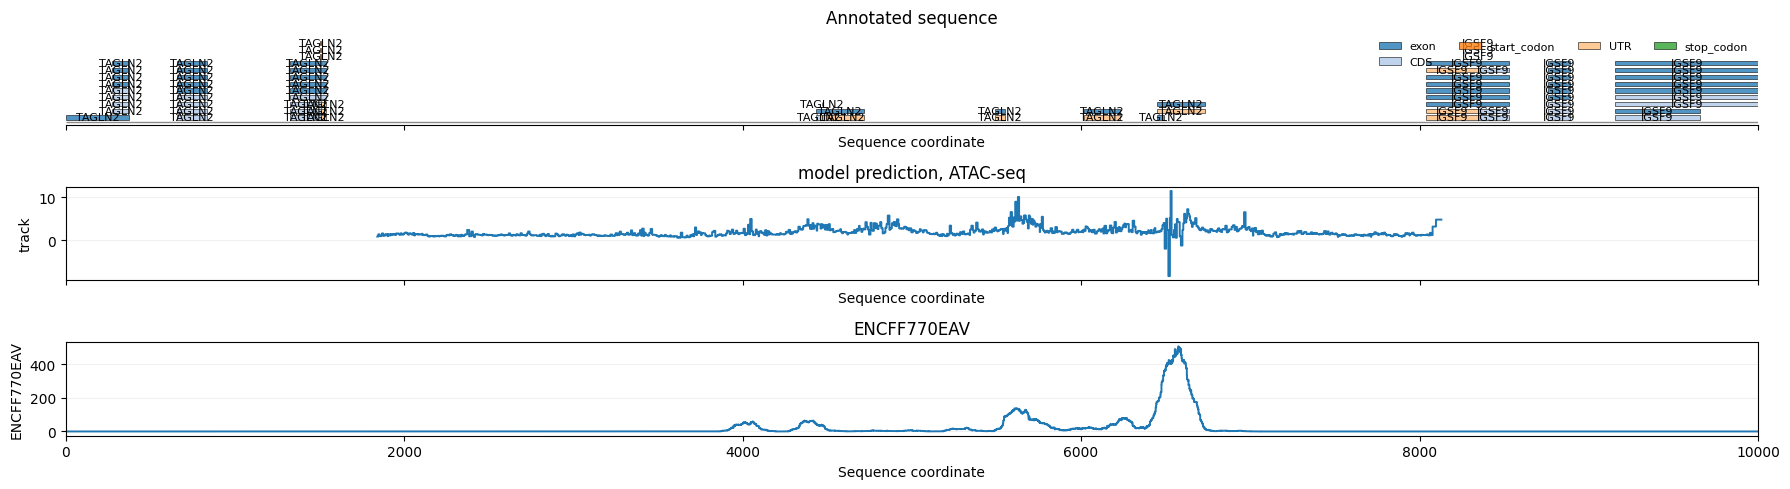

In [27]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

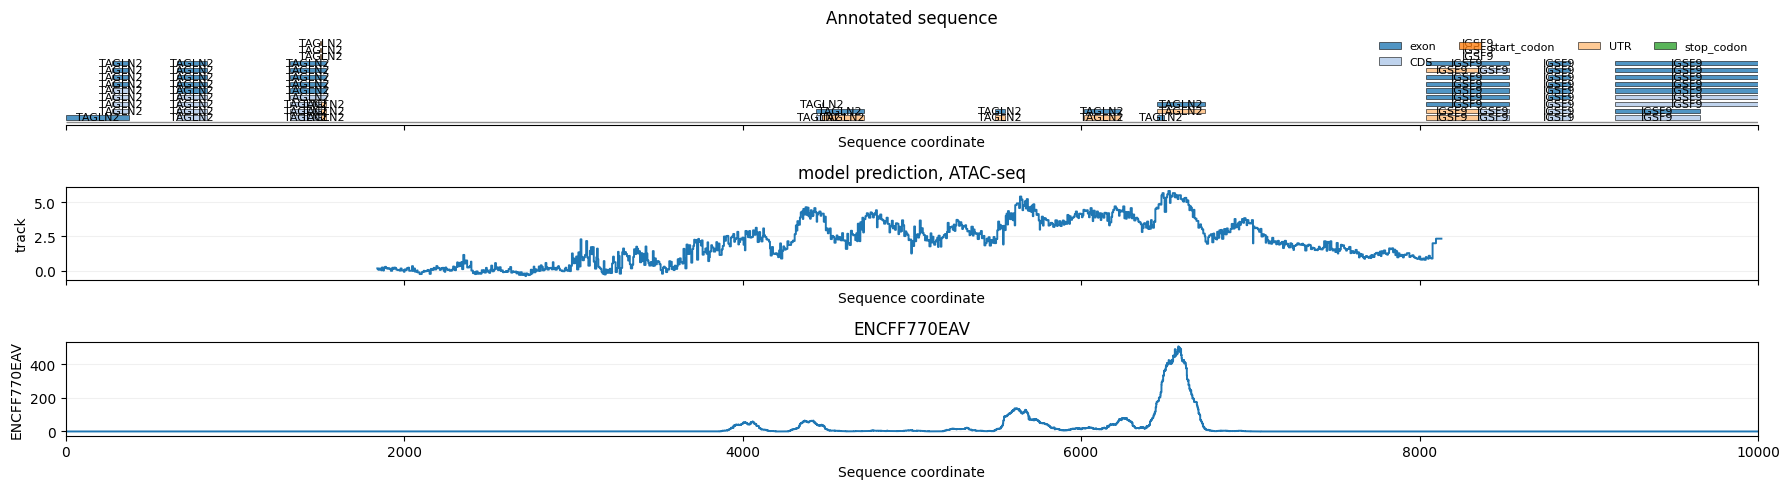

In [13]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [28]:
[value for value in prediction.track().values if value<0]

[-1.9140625, -8.25, -1.1875]

In [6]:
sequence = genome.sequence_around(center=178_480_000, chrom='chr2', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr2',
              center=178_480_000,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

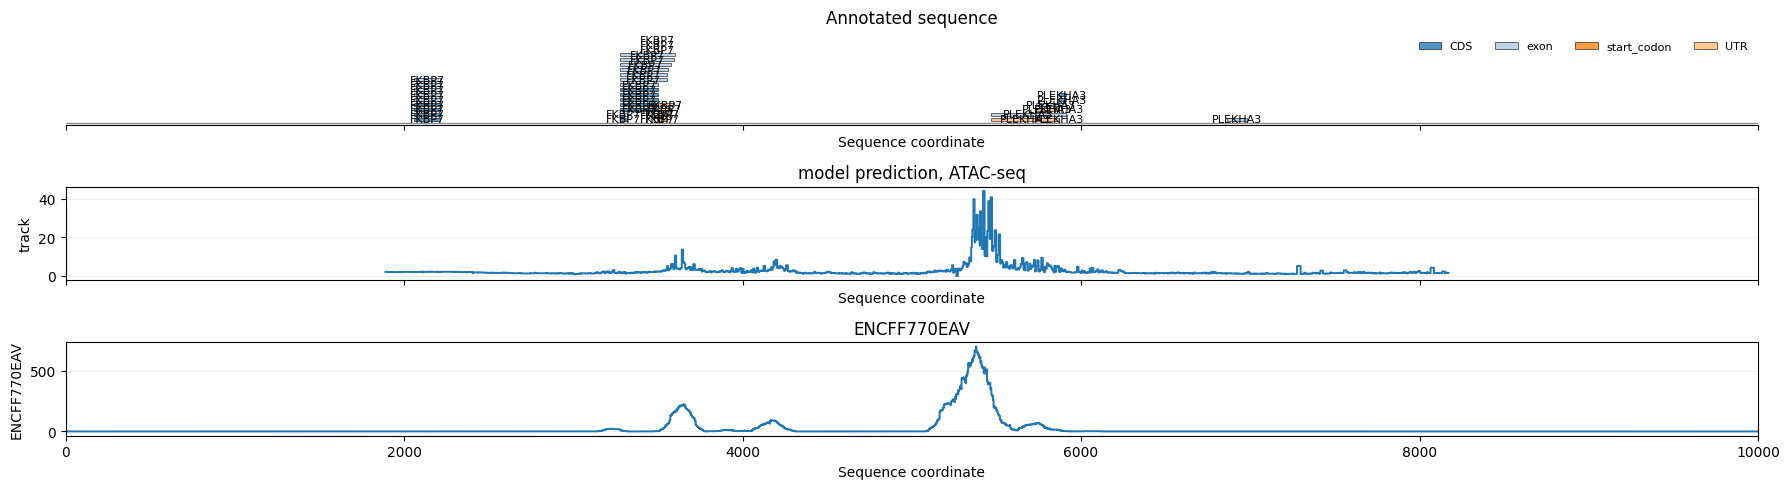

In [23]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [8]:
sequence = genome.sequence_around(center=178_523_000, chrom='chr2', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr2',
              center=178_523_000,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

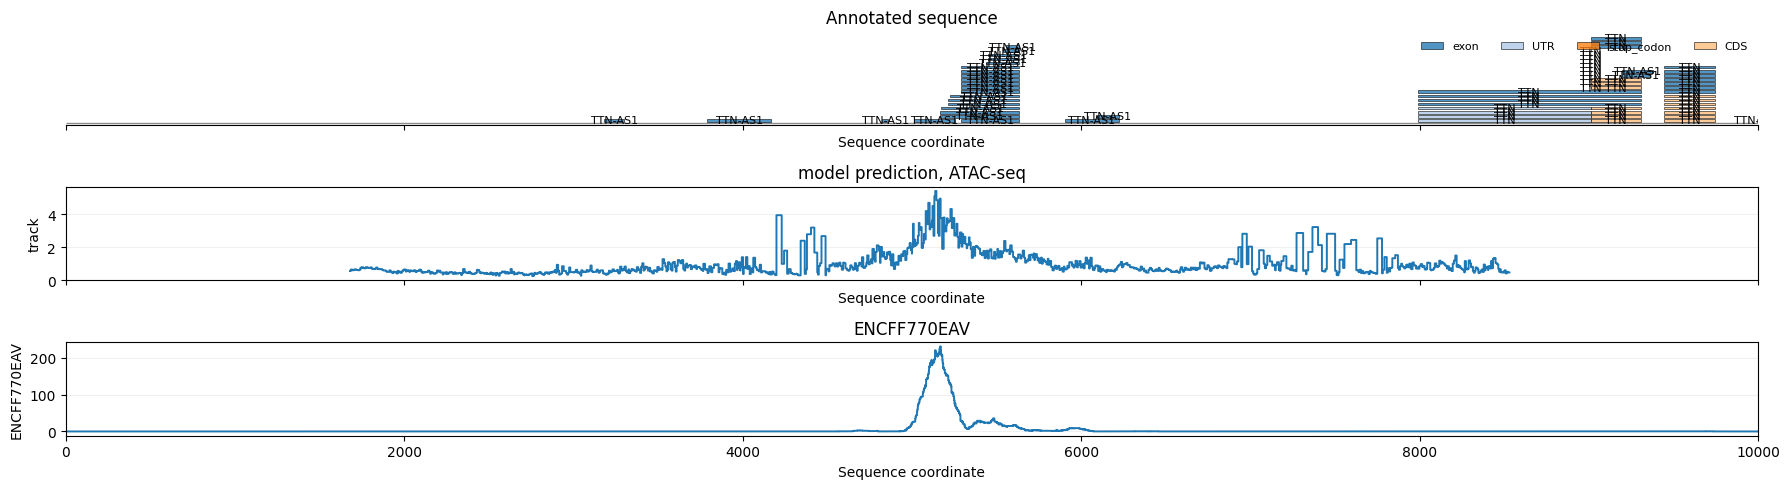

In [30]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

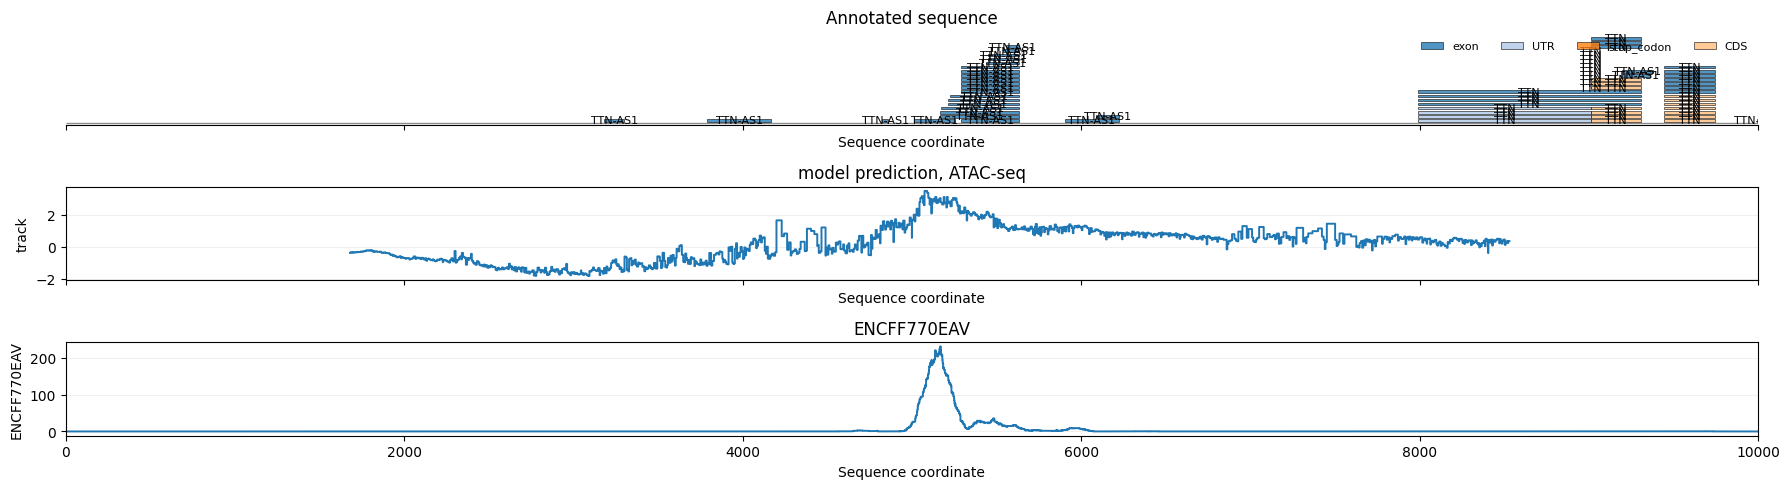

In [9]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

In [10]:
sequence = genome.sequence_around(center=6_829_000, chrom='chr12', strand='+', size=10_000)
prediction = model.predict_sequence(sequence=sequence, center=5000, condition=lookup['IMR-90'])

reference = Track.from_bw(path='/workspace-SR003.nfs2/estsoi/ENCFF770EAV.bigWig',
              chrom='chr12',
              center=6_829_000,
              size=10_000)

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

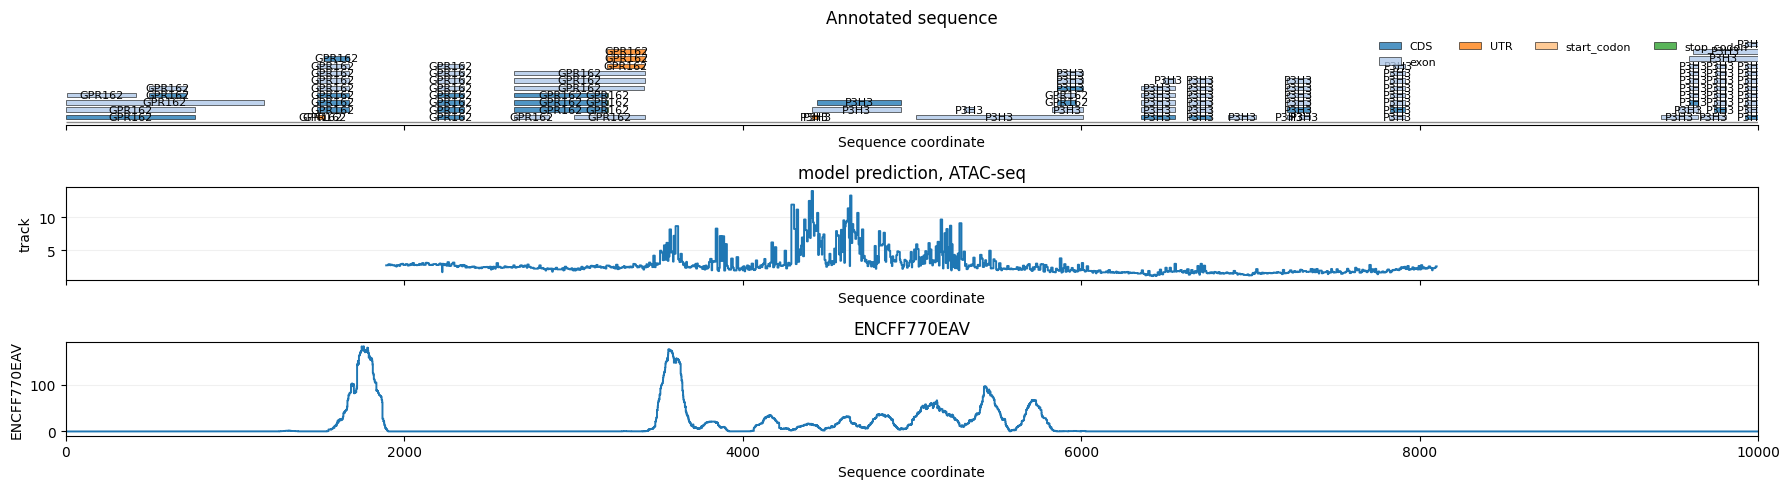

In [32]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])

(<Figure size 1800x500 with 3 Axes>,
 <Axes: title={'center': 'ENCFF770EAV'}, xlabel='Sequence coordinate', ylabel='ENCFF770EAV'>)

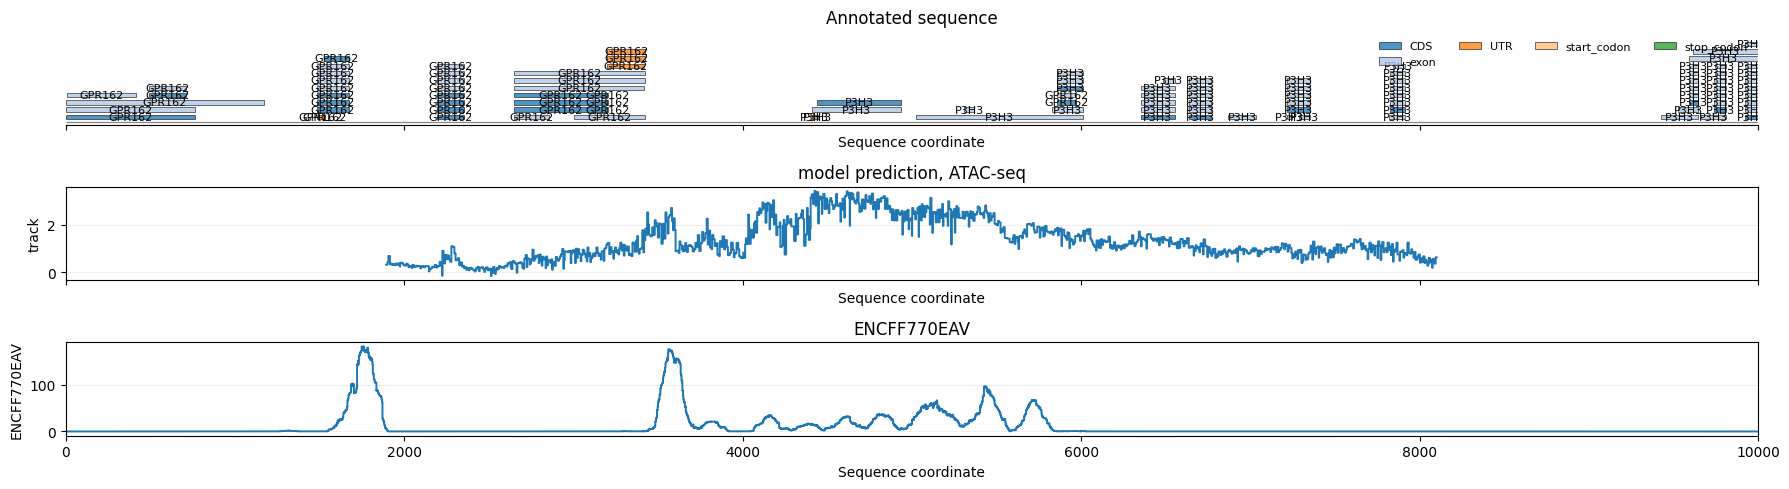

In [11]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(18, 5), sharex=True)
sequence.plot_annotations(ax=axs[0], hide_types=('source', 'transcript', 'gene', 'genome_interval'))
prediction.track().plot(ax=axs[1], color_by_sign=False, title='model prediction, ATAC-seq')
reference.plot(color_by_sign=False, ax=axs[2])